In [49]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision  # has different datasets and pretrained CNNs and utilities for image transformation
from torchvision.datasets import CIFAR10

In [50]:
### Datasets & Dataloaders

from torch.utils.data import DataLoader
import torchvision.transforms as transforms  # used to perform transformations

# Scaling (0,1) & Normalization (-1,1)

transform = transforms.Compose(  # combines multiple tranformation and apply one after other
    [
        transforms.ToTensor(), # convert images into tensors and apply scaling 
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) # Normalization is done because , Neural networks train faster when  inputs as centered around Zero
    ]
)

trainset = CIFAR10(root="./data" , train=True , download=True ,transform=transform)
testset=CIFAR10(root="./data" , train=False , download=True ,transform=transform)

In [51]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

In [52]:
image, label = trainset[0]
print(image.size())

print(trainset.class_to_idx)

torch.Size([3, 32, 32])
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


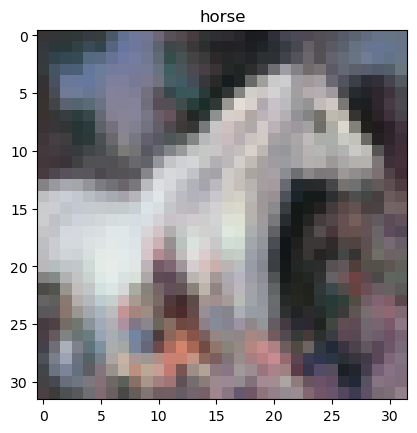

In [53]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(trainloader))

img = images[0]
img = img * 0.5 + 0.5
img = img.permute(1, 2, 0)
plt.title(trainset.classes[labels[0]])
plt.imshow(img)

# CNN

In [54]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            ##Layer 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # kernel size , stride
            ##Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            ##Layer 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4 * 4 * 128, 256), nn.ReLU(), nn.Linear(256,10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # To flatten
        x = self.fc_layers(x)

        return x

In [55]:
model = CNN()

In [56]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [57]:
from torch.utils.data import random_split

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size

train_dataset, val_dataset = random_split(trainset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64,shuffle=False)

### Training the CNN

In [58]:
epochs = 5
train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        output = model(images)  # FP
        loss = criterion(output, labels)  # loss func
        loss.backward()  # BP
        optimizer.step()  # update parameters

        running_loss += loss.item()

    epoch_training_loss = running_loss / len(train_loader)
    train_losses.append(epoch_training_loss)

    #### Evaluation ####
    model.eval()
    running_val_loss = 0.0

    correct_labels = 0
    total_labels = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct_labels += (predicted == labels).sum().item()
            total_labels += labels.size(0)

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {epoch_training_loss:.4f} "
        f"Val Loss: {epoch_val_loss:.4f} "
        f"Accuracy: {100*correct_labels/total_labels:.2f}%"
    )
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pth")

Epoch [1/5] Train Loss: 1.4094 Val Loss: 1.1378 Accuracy: 59.09%
Epoch [2/5] Train Loss: 0.9923 Val Loss: 0.9668 Accuracy: 65.34%
Epoch [3/5] Train Loss: 0.8053 Val Loss: 0.8379 Accuracy: 70.87%
Epoch [4/5] Train Loss: 0.6756 Val Loss: 0.8148 Accuracy: 71.64%
Epoch [5/5] Train Loss: 0.5606 Val Loss: 0.7907 Accuracy: 73.89%


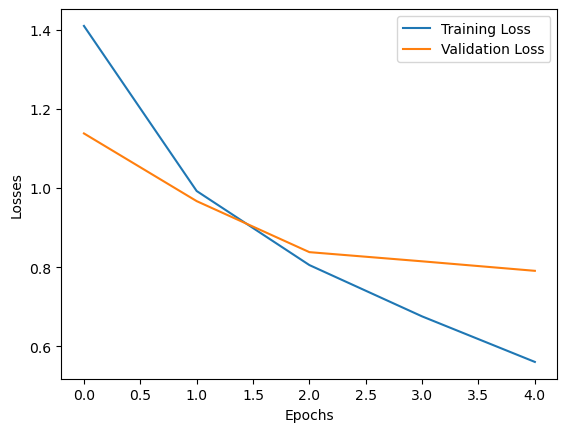

In [59]:
import pandas as pd

loss_df = pd.DataFrame({"Train_loss": train_losses, "Validation_loss": val_losses})

plt.plot(loss_df["Train_loss"], label="Training Loss")
plt.plot(loss_df["Validation_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

# Loading the best model

In [60]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

# Evaluation

In [61]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images,labels in testloader:
        outputs = model(images)

        _,predicted = torch.max(outputs,1)

        correct += (predicted==labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy : {correct/total*100}%")


Test accuracy : 73.72%


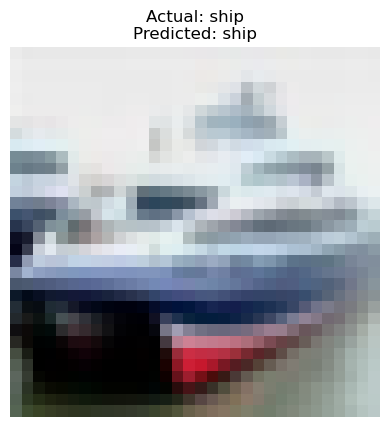

In [67]:
image, label = testset[1]

image_batch = image.unsqueeze(0)

model.eval()

with torch.no_grad():
    output = model(image_batch)
    _, predicted = torch.max(output, 1)

img = image * 0.5 + 0.5
img = img.permute(1, 2, 0)

plt.imshow(img)
plt.title(
    f"Actual: {testset.classes[label]}\nPredicted: {testset.classes[predicted.item()]}"
)
plt.axis("off")
plt.show()